In [355]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import svd
from scipy.stats import norm
from sklearn.metrics import adjusted_rand_score

# Built functions
from base import RKM, FKM, CDPCA, DGRC

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2", context="paper", font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

seed = 42
np.random.seed(seed)


In [356]:
def generate_centroids(K):
    L_c = K-1
    C_base = np.zeros((K, L_c))
    for k in range(K):
        for j in range(L_c):
            if k == j:
                C_base[k, j] = 1.0
            elif k > j:
                C_base[k, j] = -1.0 / L_c
                
    C_base = C_base - np.mean(C_base, axis=0)
    for k in range(K):
        norm = np.linalg.norm(C_base[k])
        if norm > 0:
            C_base[k] = C_base[k] / norm
    return C_base

def generate_evaluation_data(N, P_1, P_2, P_3, K, PSR, C_base):
    P = P_1 + P_2 + P_3
    L_c = K - 1
    L_d = min(P_2, 2) if P_2 > 0 else 0
    
    # Assign cluster labels evenly across the N observations
    base_labels = np.repeat(np.arange(K), int(np.ceil(N / K)))[:N]
    labels = np.random.permutation(base_labels) 
    
    # Scale the pre-calculated, fixed baseline centroids
    centroid_scale = 4
    C_true = C_base * centroid_scale
    
    # Module PSR
    var_sub = max(1e-6, 1)
    rank_amb = P - L_c - L_d
    var_amb = max(1e-6, (L_c / rank_amb) * ((1 - PSR) / PSR))
    
    # Generate within-cluster subspace residuals
    E_c = np.random.normal(0, np.sqrt(var_sub), size=(N, L_c))
    Y_c = C_true[labels] + E_c 
    
    # Construct the disjoint relevant loading matrix A_c
    A_c = np.zeros((P, L_c))
    vars_per_comp = max(1, P_1 // L_c)
    for l in range(L_c):
        start_idx = l * vars_per_comp
        end_idx = (l + 1) * vars_per_comp if l < L_c - 1 else P_1
        if end_idx > start_idx:
            A_c[start_idx:end_idx, l] = 1.0 / np.sqrt(end_idx - start_idx)
            
    # Generate and project structured masking noise (P_2 block)
    if L_d > 0 and P_2 > 0:
        var_d = (centroid_scale**2 / L_c) + var_sub
        E_d = np.random.normal(0, np.sqrt(var_d), size=(N, L_d))
        
        # Loadings for A_D
        Z = np.zeros((P, L_d))
        Z[P_1:(P_1 + P_2), :] = np.random.normal(0, 1, size=(P_2, L_d))
        U_d, _, _ = svd(Z, full_matrices=False)
        A_d = U_d[:, :L_d]
        
        A_total = np.hstack([A_c, A_d])
        X_struct = Y_c @ A_c.T + E_d @ A_d.T
    else:
        A_total = A_c
        X_struct = Y_c @ A_c.T
        
    # Generate ambient residuals for the entire space
    E_amb = np.random.normal(0, np.sqrt(var_amb), size=(N, P))
    # Project ambient noise onto the null-space of all structured loadings
    E_comp = E_amb - (E_amb @ A_total) @ A_total.T
    
    # Final observation matrix
    X = X_struct + E_comp
    
    return X, labels, L_c, L_d


def fit_models_and_evaluate(X, true_labels, K, L_c, L_d, opt_rho_1, opt_rho_2, Rndstart=15, max_iter=40):
    L_total = L_c + L_d
    results = {}
        
    # RKM
    try:
        rkm = RKM(K=K, L=L_c, Rndstart=Rndstart, maxiter=max_iter).fit(X)
        results['RKM'] = adjusted_rand_score(true_labels, np.argmax(rkm.U, axis=1))
    except Exception:
        results['RKM'] = 0.0
    
    # FKM
    try:
        fkm = FKM(K=K, L=L_c, Rndstart=Rndstart, maxiter=max_iter).fit(X)
        results['FKM'] = adjusted_rand_score(true_labels, np.argmax(fkm.U, axis=1))
    except Exception:
        results['FKM'] = 0.0
        
    # CDPCA
    try:
        cdpca = CDPCA(K=K, L=L_c, Rndstart=Rndstart, maxiter=max_iter).fit(X)
        results['CDPCA'] = adjusted_rand_score(true_labels, np.argmax(cdpca.U, axis=1))
    except Exception:
        results['CDPCA'] = 0.0
        
    # DGRC (Single execution using passed optimal parameters)
    try:
        dgrc = DGRC(K=K, L=L_total, L_d=L_d, rho_1=opt_rho_1, rho_2=opt_rho_2, Rndstart=Rndstart, maxiter=max_iter).fit(X)
        results['DGRC'] = adjusted_rand_score(true_labels, np.argmax(dgrc.U, axis=1))
    except Exception:
        results['DGRC'] = 0.0
    
    return results

In [ ]:
## Cross validation
def tune_dgrc_hyperparameters(N, P_1, P_2, P_3, K, psr, C_base, cv_trials=3, Rndstart=15, max_iter=50):
    L_c = K - 1
    L_d = min(P_2, 2) if P_2 > 0 else 0
    L_total = L_c + L_d

    # Bypass tuning if there are no disturbing dimensions
    if L_d == 0:
        return 1.0, 0.0 

    rho_1_vals = [1.0, 1.5, 2.0, 2.5, 3.0]
    rho_2_vals = [0.0, 0.5, 1.0, 1.5, 2.0]
    rho_grid = [(r1, r2) for r1 in rho_1_vals for r2 in rho_2_vals if r1 > r2]

    best_overall_loss = np.inf
    best_rho = rho_grid[0]

    # Generate a small set of validation matrices for this specific PO/PSR condition
    val_datasets = [generate_evaluation_data(N, P_1, P_2, P_3, K, psr, C_base) for _ in range(cv_trials)]

    for r1, r2 in rho_grid:
        current_grid_loss = 0
        valid_fits = 0
        
        for X_val, _, _, _ in val_datasets:
            try:
                dgrc = DGRC(K=K, L=L_total, L_d=L_d, rho_1=r1, rho_2=r2, Rndstart=Rndstart, maxiter=max_iter).fit(X_val)
                if hasattr(dgrc, 'loss'):
                    current_grid_loss += dgrc.loss
                    valid_fits += 1
            except Exception:
                continue
        
        # Select parameters that minimise average trace loss across the CV trials
        if valid_fits > 0:
            avg_loss = current_grid_loss / valid_fits
            if avg_loss < best_overall_loss:
                best_overall_loss = avg_loss
                best_rho = (r1, r2)

    return best_rho[0], best_rho[1]

In [ ]:
def run_psr_evaluation(n_trials, cv_trials=3, Rndstart=15):
    print("Executing: Robustness against Subspace Residuals and Spatial Overlap evaluation")
    N, P_1, P_2, P_3, K = 200, 6, 6, 12, 4
    
    # psr sweep values
    #psr_spectrum = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
    psr_spectrum = [0.001, 0.01, 0.02, 0.03, 0.045, 0.06, 0.08, 0.1]
    records = []
    C_base = generate_centroids(K)
    
    # PSR sweep
    for psr in psr_spectrum:
        print(f"Tuning DGRC for PSR = {psr}")
        opt_r1, opt_r2 = tune_dgrc_hyperparameters(N, P_1, P_2, P_3, K, psr, C_base, cv_trials, Rndstart)
        
        for _ in range(n_trials):
            X, true_labels, L_c, L_d = generate_evaluation_data(N, P_1, P_2, P_3, K, psr, C_base)
            eval_res = fit_models_and_evaluate(X, true_labels, K, L_c, L_d, opt_r1, opt_r2)
            for algo, ari in eval_res.items():
                records.append({'Evaluation': 'Varying PSR', 'Level': psr, 'Algorithm': algo, 'ARI': ari})

    return pd.DataFrame(records)


def run_N_P_evaluation(n_trials, cv_trials=3, Rndstart=15):
    print("Executing: Noise dimension-scaling evaluation")
    P, K = 25, 4
    fixed_psr = 0.03
    
    N_levels = [100, 200, 300]
    P2_levels = [0, 5, 10]
    P3_levels = [0, 5]
    
    C_base = generate_centroids(K)
    records = []
    for p3 in P3_levels:
        for p2 in P2_levels:
            p1 = P - (p2+p3)
            print(f"P_2={p2}, P_3={p3}")
            opt_r1, opt_r2 = tune_dgrc_hyperparameters(400, p1, p2, p3, K, fixed_psr, C_base, cv_trials, Rndstart)
            for n in N_levels:
                for _ in range(n_trials):
                    X, true_labels, L_c, L_d = generate_evaluation_data(n, p1, p2, p3, K, fixed_psr, C_base)
                    eval_res = fit_models_and_evaluate(X, true_labels, K, L_c, L_d, opt_r1, opt_r2)
                    for algo, ari in eval_res.items():
                        records.append({'P3': p3, 'P2': p2, 'N': n, 'Algorithm': algo, 'ARI': ari})
                        
    return pd.DataFrame(records)

In [359]:
df_psr = run_psr_evaluation(80)
df_N_P = run_N_P_evaluation(80)

print("Simulations complete")

df_psr.to_csv('psr_po_sims.csv', index=False)
print(f"Successfully saved: psr_po_sims.csv")
df_N_P.to_csv('psr_N_P.csv', index=False)
print(f"Successfully saved: psr_po_sims.csv")

Executing: Robustness against Subspace Residuals and Spatial Overlap evaluation
Tuning DGRC for PSR = 0.001
Tuning DGRC for PSR = 0.01
Tuning DGRC for PSR = 0.02
Tuning DGRC for PSR = 0.03
Tuning DGRC for PSR = 0.045
Tuning DGRC for PSR = 0.06
Tuning DGRC for PSR = 0.08
Tuning DGRC for PSR = 0.1
Executing: Noise dimension-scaling evaluation
P_2=0, P_3=0
P_2=5, P_3=0
P_2=10, P_3=0
P_2=0, P_3=5
P_2=5, P_3=5
P_2=10, P_3=5
Simulations complete
Successfully saved: psr_po_sims.csv
Successfully saved: psr_po_sims.csv


In [372]:
(df_psr['Algorithm']=='DGRC').size + (df_N_P['Algorithm']=='DGRC').size

8320

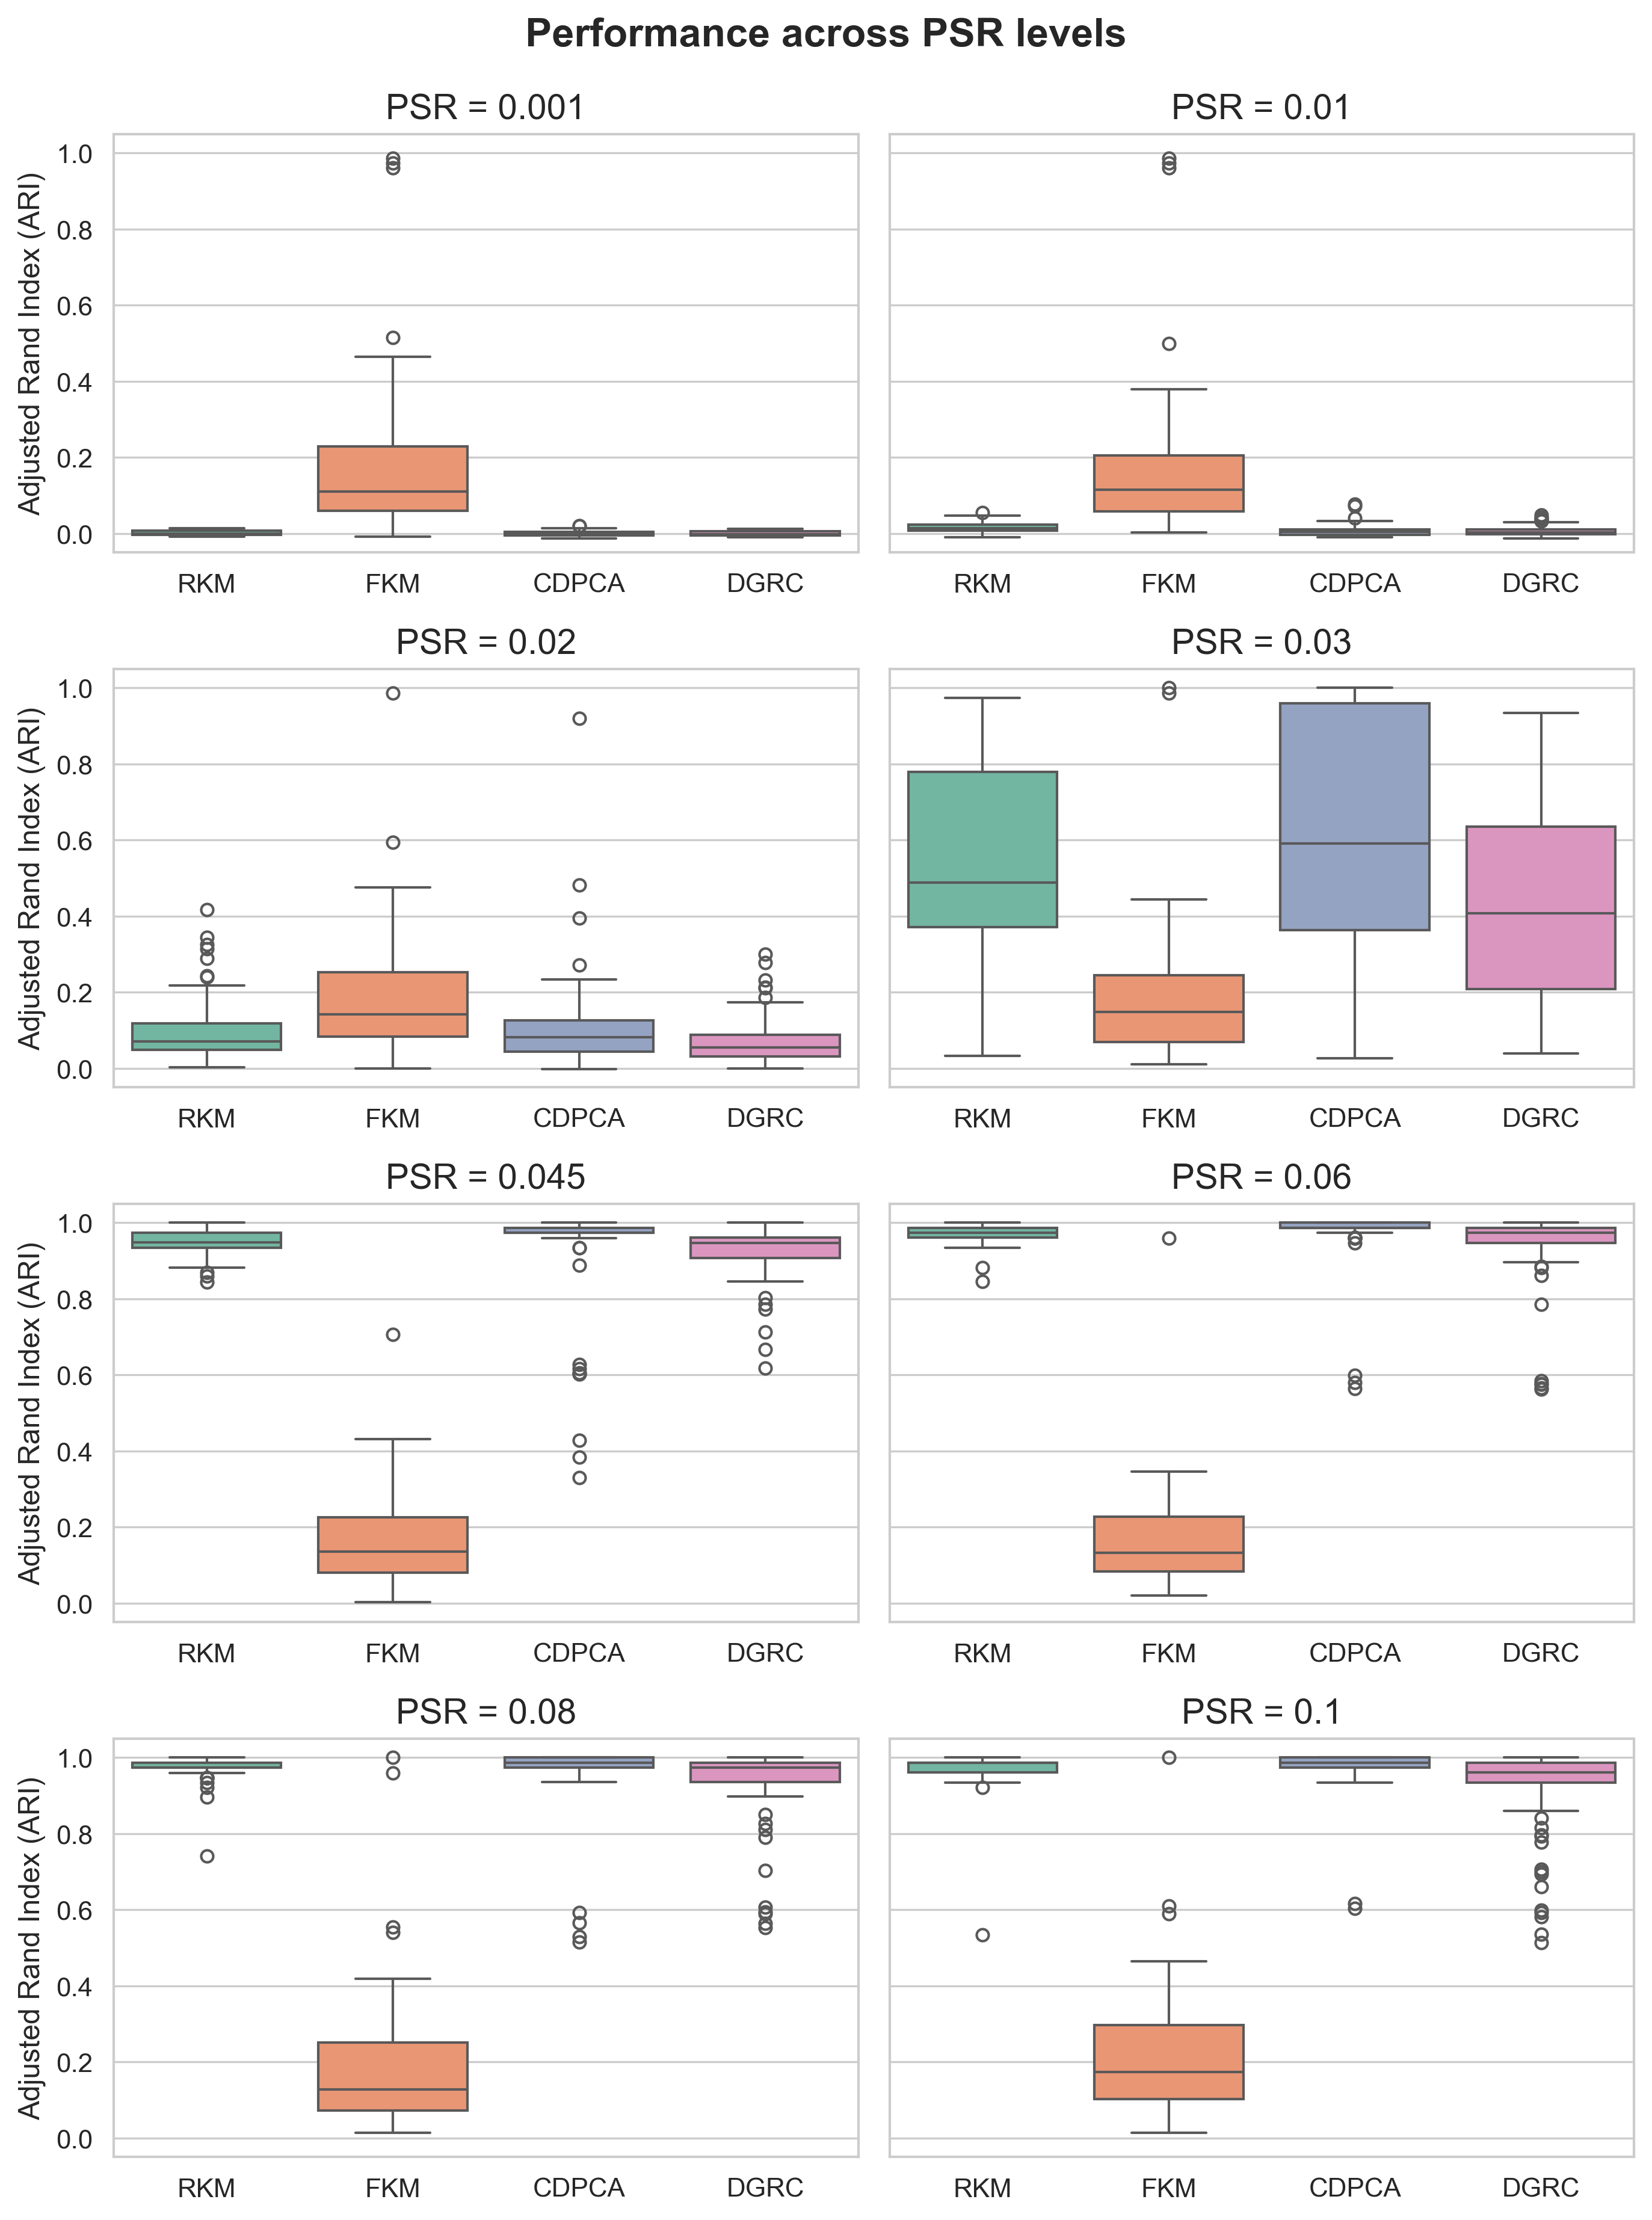

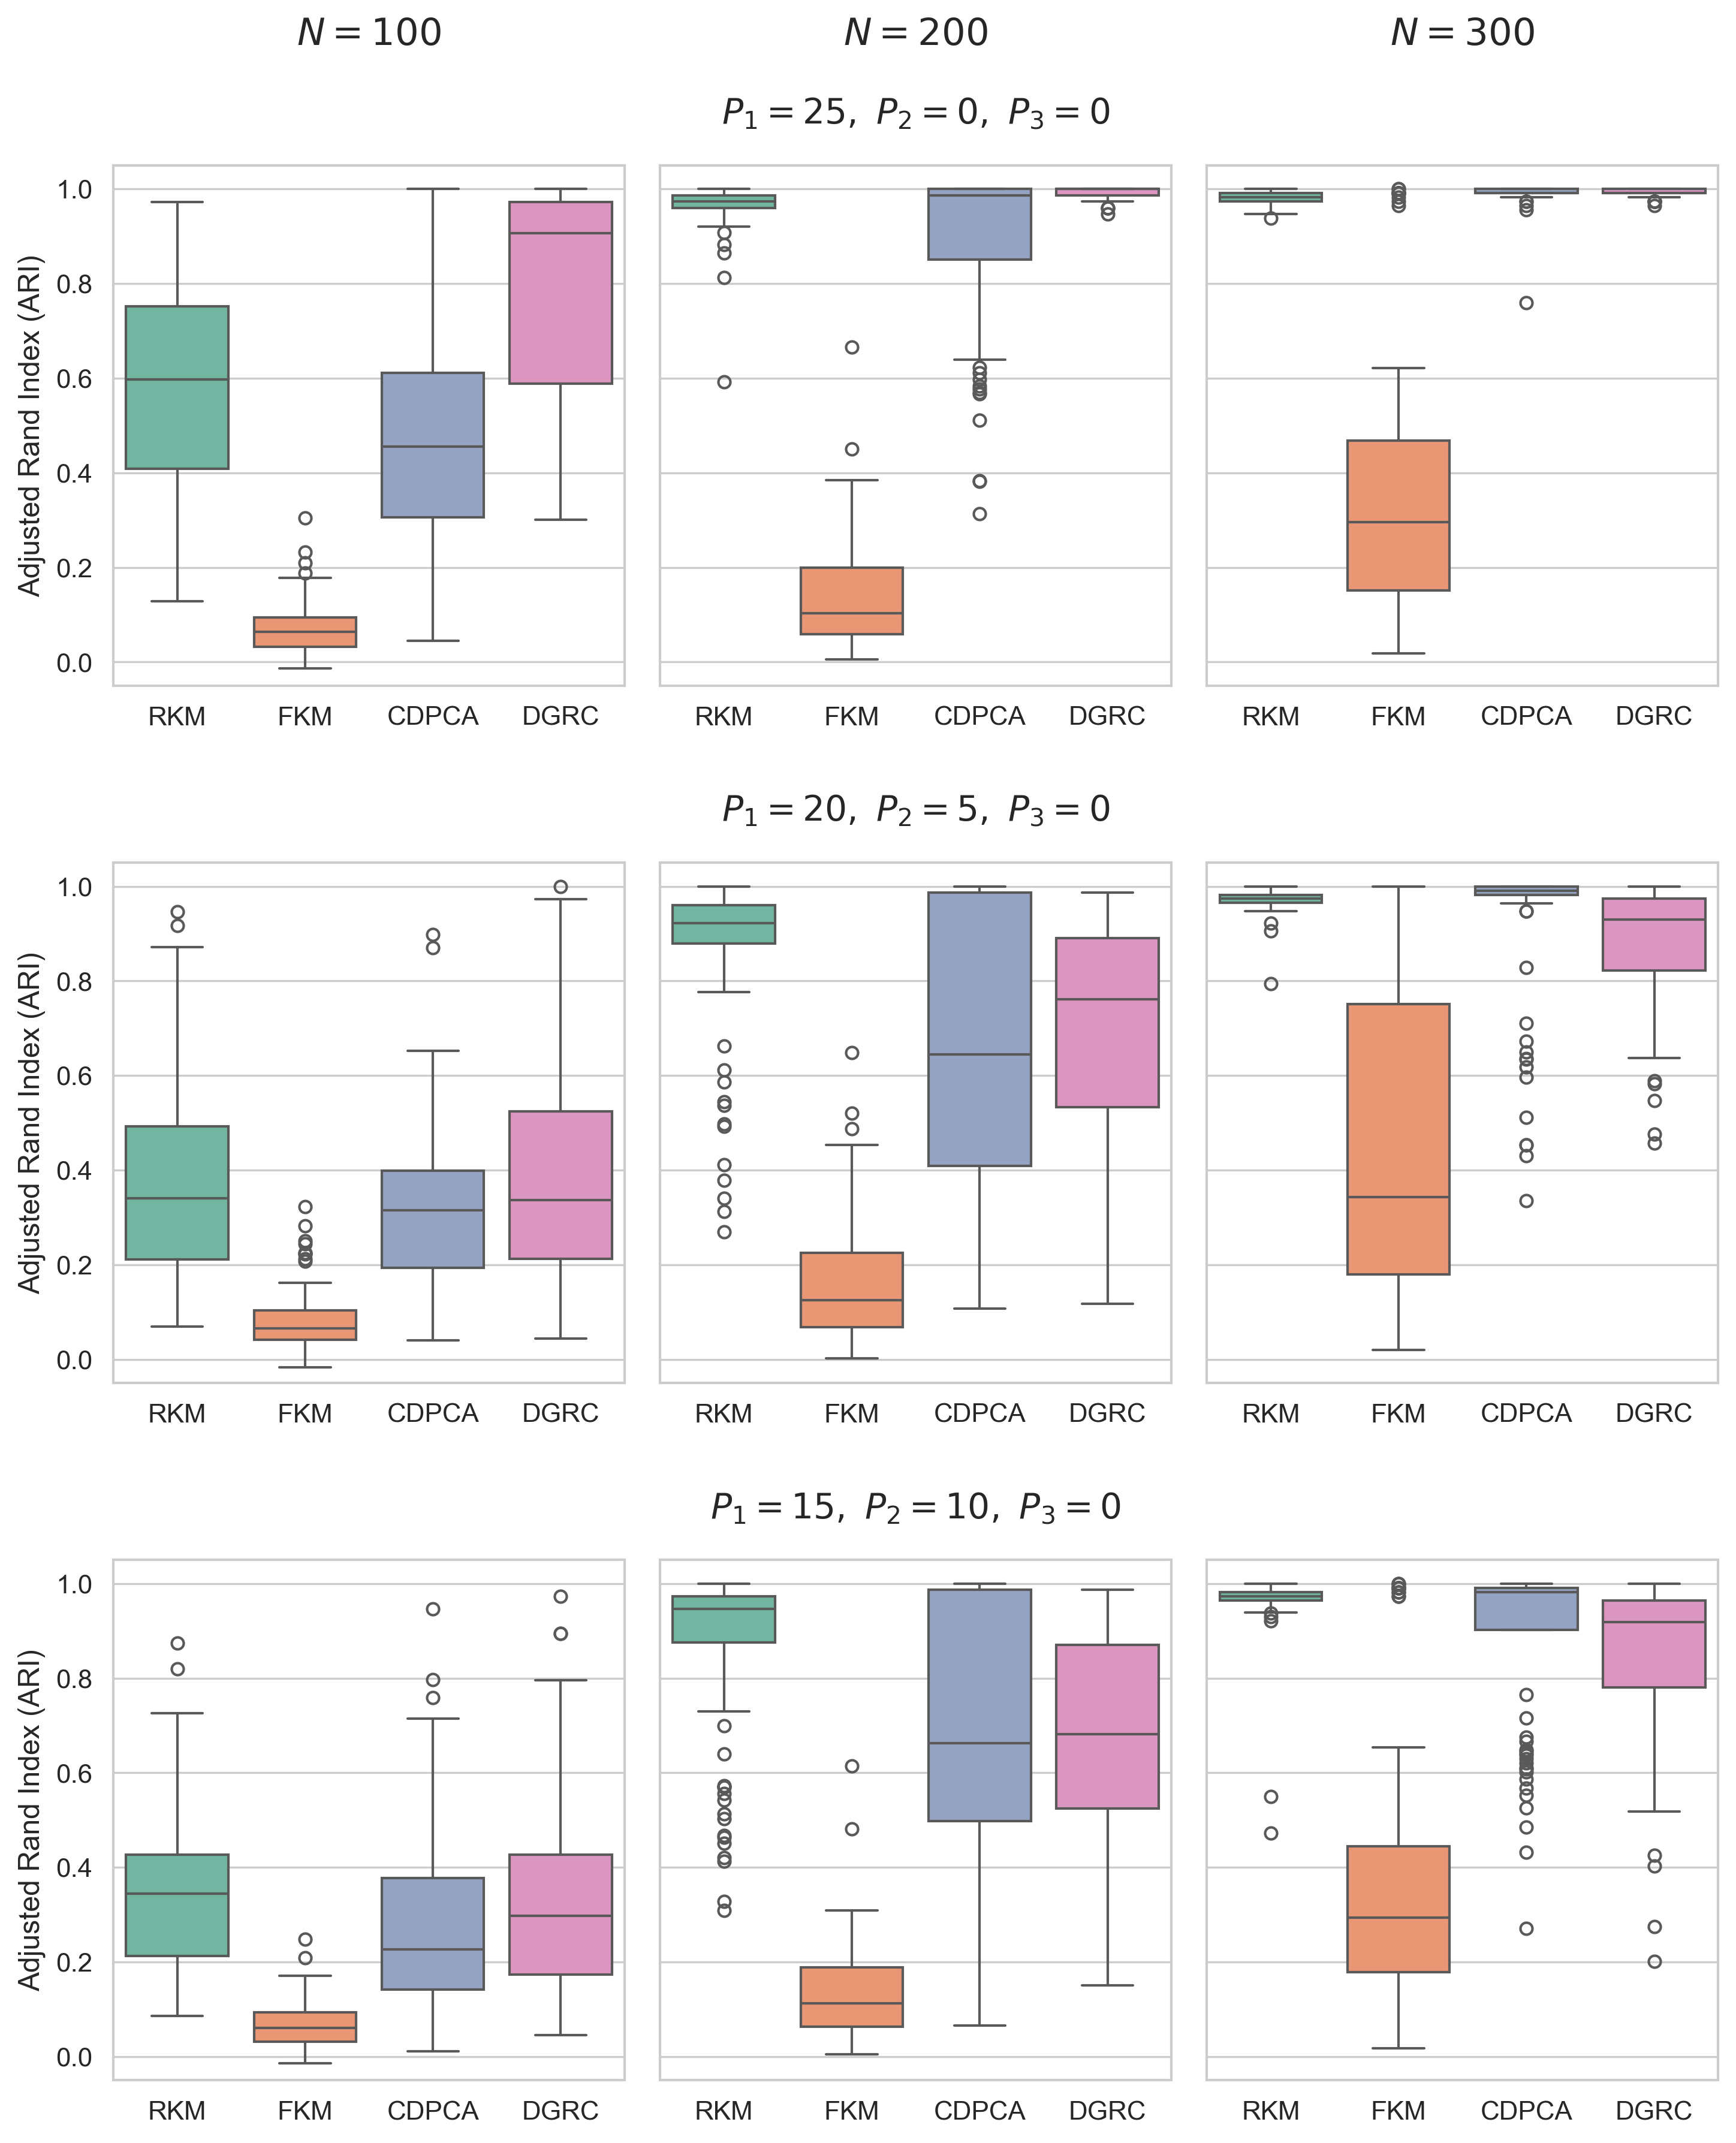

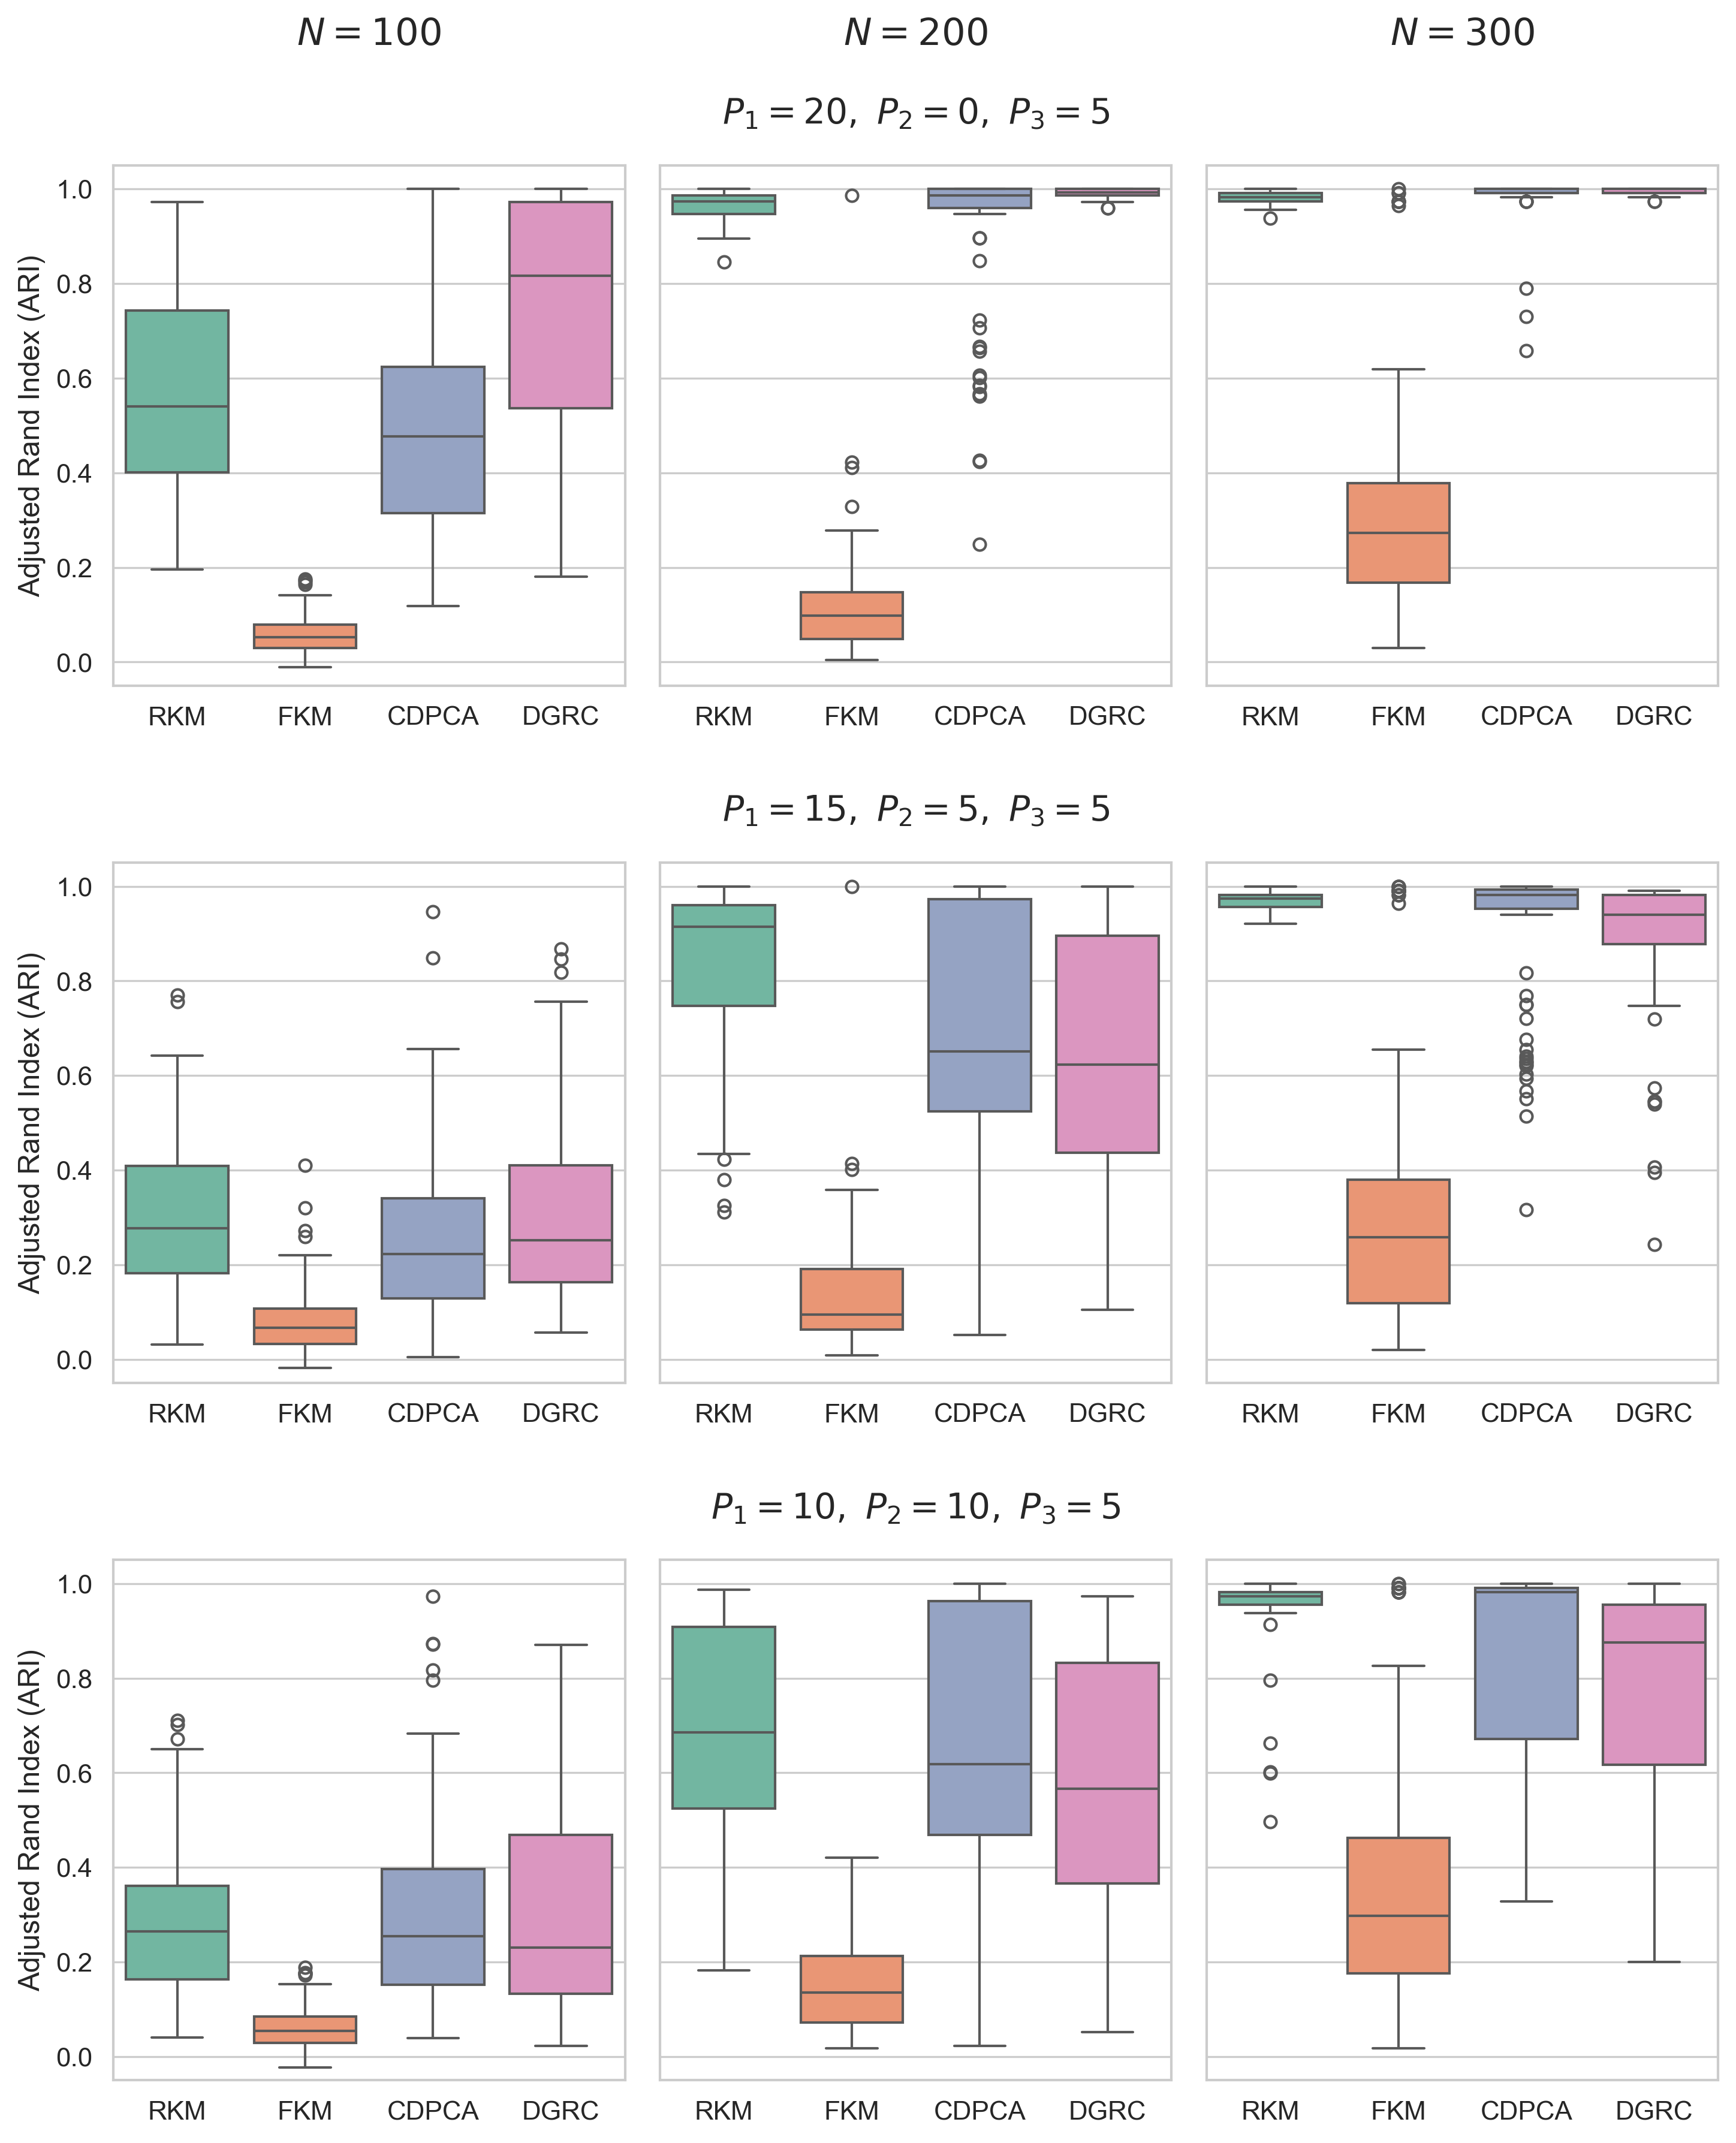

In [424]:
def plot_psr(df):
    # Fig 1, PSR
    df_psr = df[df['Evaluation'] == 'Varying PSR']
    psr_levels = sorted(df_psr['Level'].unique()) 
    
    # 4x2 plot
    fig1, axes1 = plt.subplots(4, 2, figsize=(9.3, 12.4), sharey=True)
    fig1.suptitle('Performance across PSR levels', fontweight='bold', fontsize=16, y=0.99)
    
    for ax, level in zip(axes1.flatten(), psr_levels):
        subset = df_psr[df_psr['Level'] == level]
        sns.boxplot(data=subset, x='Algorithm', y='ARI', ax=ax, palette='Set2')

        ax.set_title(f'PSR = {level}', fontweight='normal', fontsize=14)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel('')
        # ylabel for left-most
        if ax.get_subplotspec().is_first_col():
            ax.set_ylabel('Adjusted Rand Index (ARI)')
        else:
            ax.set_ylabel('')
            
    plt.tight_layout()
    plt.savefig("psr_plots.pdf", format='pdf', bbox_inches='tight')
    plt.show()


def plot_N_P(df):
    P3_levels = sorted(df['P3'].unique())
    P2_levels = sorted(df['P2'].unique())
    N_levels = sorted(df['N'].unique())
    
    P = 25
    
    for p3 in P3_levels:
        fig, axes = plt.subplots(nrows=len(P2_levels), ncols=len(N_levels), 
                                 figsize=(9.8, 12.3), sharey=True)
        
        for i, p2 in enumerate(P2_levels):
            p1 = P - p2 - p3
            for j, n in enumerate(N_levels):
                ax = axes[i, j]
                subset = df[(df['P3'] == p3) & (df['P2'] == p2) & (df['N'] == n)]
                sns.boxplot(data=subset, x='Algorithm', y='ARI', ax=ax, palette='Set2')
                ax.set_title('')

                if i == 0:
                    ax.annotate(rf'$N = {n}$', xy=(0.5, 1.25), xycoords='axes fraction', 
                                ha='center', va='center', fontsize=15, fontweight='bold')
                
                # title across row
                if j == len(N_levels) // 2:
                    x_offset = 0.5 if len(N_levels) % 2 != 0 else 0.0
                    
                    ax.annotate(rf'$P_1={p1},\ P_2={p2},\ P_3={p3}$', 
                                xy=(x_offset, 1.10), xycoords='axes fraction', 
                                ha='center', va='center', fontsize=14)
                
                ax.set_ylim(-0.05, 1.05)
                ax.set_xlabel('')
                if j == 0:
                    ax.set_ylabel('Adjusted Rand Index (ARI)')
                else:
                    ax.set_ylabel('')
                    
        plt.tight_layout()
        fig.subplots_adjust(top=0.90, hspace=0.34)
        plt.savefig(f"NP_P3_eq_{p3}_plots.pdf", format='pdf', bbox_inches='tight')
        plt.show()

plot_psr(df_psr)
plot_N_P(df_N_P)